In [3]:
! pip install timesfm[gpu]
! pip install timesfm[torch]
! pip install timesfm[xreg]

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# TimesFM
import time
import torch
import timesfm
import warnings
warnings.filterwarnings('ignore')

In [5]:
BASE = Path('/content/tesis-bolsa/data/processed')
df = pd.read_parquet(BASE / 'dataset_consolidado.parquet')
df.index = pd.to_datetime(df.index)

# Train/test
train = df[df.index < '2025-07-13']
test = df[df.index >= '2025-07-13']

covariables = ['gen_termica', 'ONI', 'aportes_energia_gwh']

print(f"Train: {train.index.min().date()} → {train.index.max().date()} ({len(train)} días)")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()} ({len(test)} días)")

Train: 2013-01-01 → 2025-07-12 (4576 días)
Test:  2025-07-13 → 2026-05-01 (293 días)


In [6]:
torch.set_float32_matmul_precision("high")

model_timesfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

# Predicción univariante en test

In [7]:
horizonte_test = len(test)
serie_target = train['precio_bolsa'].values

model_timesfm.compile(
    timesfm.ForecastConfig(
        max_context=len(serie_target),
        max_horizon=horizonte_test,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)

t0 = time.time()
point_forecast, quantile_forecast = model_timesfm.forecast(
    horizon=horizonte_test,
    inputs=[serie_target],
)
tt_uni = time.time() - t0

# Predicción puntual y banda de incertidumbre (p10-p90)
punto_uni = point_forecast[0]
cuantiles_uni = quantile_forecast[0]
p10_uni = cuantiles_uni[:, 1]
p90_uni = cuantiles_uni[:, -1]

pred_timesfm_uni = pd.Series(punto_uni, index=test.index, name='precio_bolsa')
print(pred_timesfm_uni.head())

Fecha
2025-07-13    127.642380
2025-07-14    130.314575
2025-07-15    132.887680
2025-07-16    133.414276
2025-07-17    133.769714
Name: precio_bolsa, dtype: float32


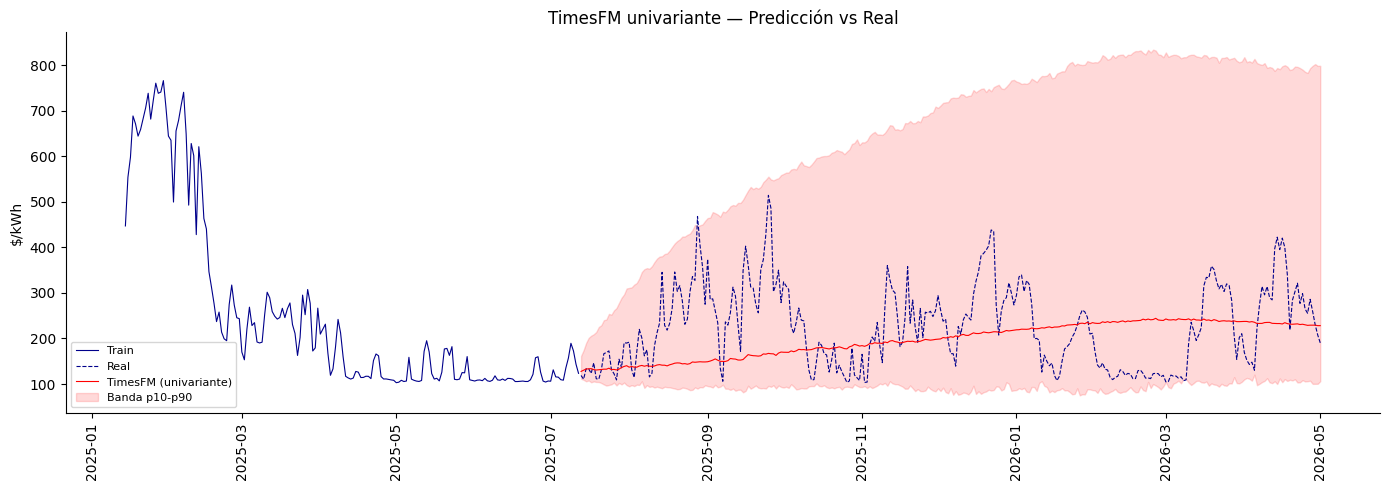

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Train')
ax.plot(test.index, test['precio_bolsa'], color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(test.index, pred_timesfm_uni, color='red', linewidth=0.8, label='TimesFM (univariante)')
ax.fill_between(test.index, p10_uni, p90_uni, color='red', alpha=0.15, label='Banda p10-p90')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('TimesFM univariante — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()

# Predicción con covariables sobre Test

In [9]:
dynamic_numerical_covariates = {
    col: [np.concatenate([train[col].values, test[col].values])]
    for col in covariables
}

model_timesfm.compile(
    timesfm.ForecastConfig(
        max_context=len(serie_target),
        max_horizon=horizonte_test,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
        return_backcast=True,
    )
)

t0 = time.time()

point_forecast_cov, quantile_forecast_cov = model_timesfm.forecast_with_covariates(
    inputs=[serie_target],
    dynamic_numerical_covariates=dynamic_numerical_covariates,
    dynamic_categorical_covariates=None,
    static_numerical_covariates=None,
    static_categorical_covariates=None,
    xreg_mode="xreg + timesfm",  # combina regresión lineal sobre covariables + residual con TimesFM
)
tt_cov = time.time() - t0

pred_timesfm_cov = pd.Series(np.asarray(point_forecast_cov[0]), index=test.index, name='precio_bolsa')
print(pred_timesfm_cov.head())

Fecha
2025-07-13    100.100241
2025-07-14    142.514412
2025-07-15     90.624621
2025-07-16     82.304854
2025-07-17     72.412216
Name: precio_bolsa, dtype: float64


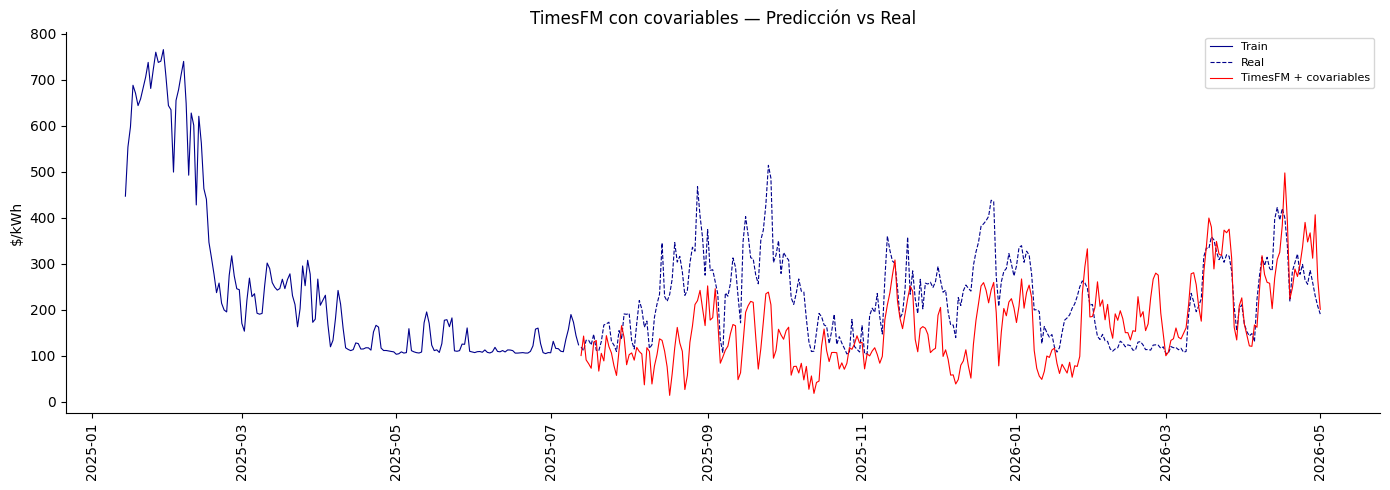

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Train')
ax.plot(test.index, test['precio_bolsa'], color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(test.index, pred_timesfm_cov, color='red', linewidth=0.8, label='TimesFM + covariables')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('TimesFM con covariables — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()

## Métricas (MASE, RMSSE, MAE, RMSE, MAPE, SMAPE, R2, TT(Sec) )

In [11]:
def calcular_metricas(real, pred, serie_contexto, m=7, tt_sec=None):
    real = np.asarray(real, dtype=float)
    pred = np.asarray(pred, dtype=float)

    error = real - pred
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    mape = np.mean(np.abs(error / real)) * 100
    smape = np.mean(np.abs(error) / ((np.abs(real) + np.abs(pred)) / 2)) * 100

    ss_res = np.sum(error ** 2)
    ss_tot = np.sum((real - np.mean(real)) ** 2)
    r2 = 1 - ss_res / ss_tot

    # Escalamiento con un naive estacional de periodo m sobre el contexto (train)
    naive_diff = np.abs(np.diff(serie_contexto, n=1)) if m == 1 else np.abs(
        np.asarray(serie_contexto[m:]) - np.asarray(serie_contexto[:-m])
    )
    escala_mae = np.mean(naive_diff)
    escala_rmse = np.sqrt(np.mean(naive_diff ** 2))

    mase = mae / escala_mae
    rmsse = rmse / escala_rmse

    return {
        'MASE': round(mase, 3),
        'RMSSE': round(rmsse, 3),
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape, 2),
        'SMAPE': round(smape, 2),
        'R2': round(r2, 3),
        'TT (Sec)': round(tt_sec, 2) if tt_sec is not None else None,
    }

In [12]:
real = test['precio_bolsa']
resultados_timesfm = {}

resultados_timesfm['TimesFM (univariante)'] = calcular_metricas(
    real, pred_timesfm_uni, serie_contexto=serie_target, m=7, tt_sec=tt_uni
)
resultados_timesfm['TimesFM + covariables'] = calcular_metricas(
    real, pred_timesfm_cov, serie_contexto=serie_target, m=7, tt_sec=tt_cov
)

print(f"Precio promedio test: {real.mean():.2f} $/kWh\n")
tabla_metricas = pd.DataFrame(resultados_timesfm).T
tabla_metricas = tabla_metricas[['MASE', 'RMSSE', 'MAE', 'RMSE', 'MAPE', 'SMAPE', 'R2', 'TT (Sec)']]
tabla_metricas

Precio promedio test: 225.93 $/kWh



,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
TimesFM (univariante),1.218,0.748,82.29,102.51,39.09,37.66,-0.299,1.80
TimesFM + covariables,1.283,0.770,86.72,105.57,38.72,48.25,-0.378,3.57


# Predicción a un horizonte futuro

## Univariante:

In [13]:
horizonte_futuro = 30  # días a pronosticar

serie_completa = df['precio_bolsa'].values

# Frecuencia de las fechas del dataset
freq_datos = pd.infer_freq(df.index) or 'D'
fechas_futuras = pd.date_range(
    start=df.index.max() + pd.Timedelta(days=1),
    periods=horizonte_futuro,
    freq=freq_datos
)

model_timesfm.compile(
    timesfm.ForecastConfig(
        max_context=len(serie_completa),
        max_horizon=horizonte_futuro,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)

point_forecast_fut, quantile_forecast_fut = model_timesfm.forecast(
    horizon=horizonte_futuro,
    inputs=[serie_completa],
)

punto_fut = point_forecast_fut[0]
cuantiles_fut = quantile_forecast_fut[0]
p10_fut = cuantiles_fut[:, 1]
p90_fut = cuantiles_fut[:, -1]

df_forecast_futuro = pd.DataFrame({
    'Punto': punto_fut,
    'p10': p10_fut,
    'p90': p90_fut,
}, index=fechas_futuras)

print(df_forecast_futuro)

                 Punto         p10         p90
2026-05-02  186.819519  160.815933  239.620544
2026-05-03  187.688446  154.462616  256.228699
2026-05-04  189.081909  144.683090  274.416138
2026-05-05  192.042938  140.741867  291.560425
2026-05-06  191.837601  130.622314  302.420959
2026-05-07  191.608276  124.228394  311.219604
2026-05-08  189.356293  117.247253  317.857361
2026-05-09  188.779999  114.635406  328.069763
2026-05-10  189.004333  110.407013  328.831329
2026-05-11  191.927032  109.552521  338.308777
2026-05-12  193.299469  103.507797  345.488373
2026-05-13  198.001068  107.528809  361.395203
2026-05-14  194.949127  107.058441  361.969818
2026-05-15  193.882446  109.998840  365.510315
2026-05-16  190.802063  106.301041  362.310059
2026-05-17  191.701019  112.943375  366.314636
2026-05-18  194.904205  110.838226  373.578308
2026-05-19  196.345459  112.164688  379.271423
2026-05-20  200.581085  107.288330  394.694092
2026-05-21  196.104294  105.984482  394.462860
2026-05-22  1

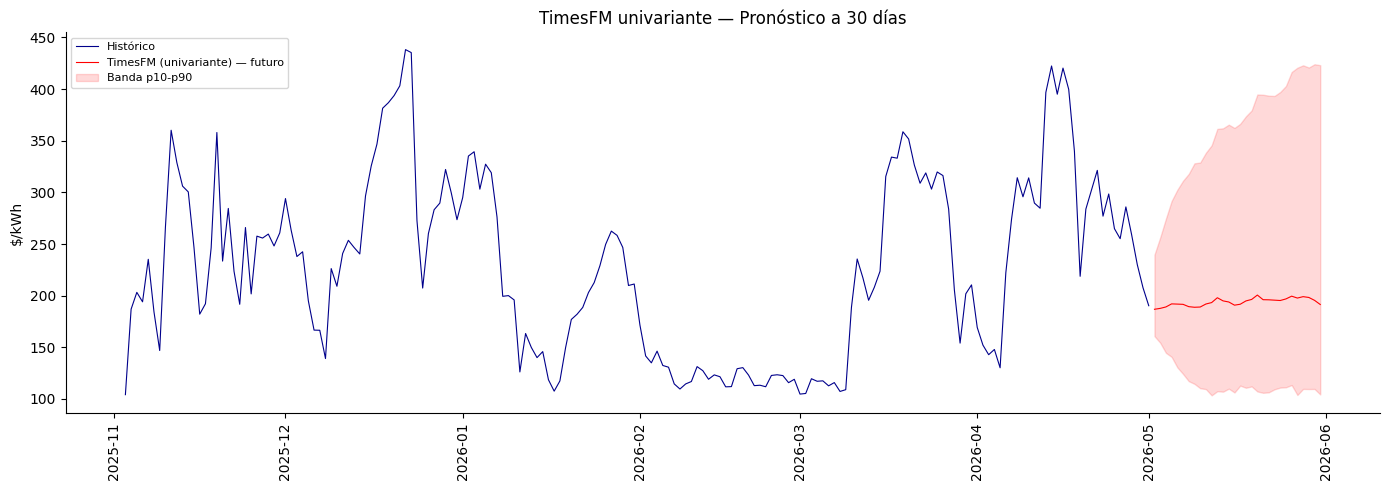

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[-180:], df['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Histórico')
ax.plot(df_forecast_futuro.index, df_forecast_futuro['Punto'], color='red', linewidth=0.8, label='TimesFM (univariante) — futuro')
ax.fill_between(df_forecast_futuro.index, df_forecast_futuro['p10'], df_forecast_futuro['p90'],
                 color='red', alpha=0.15, label='Banda p10-p90')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title(f'TimesFM univariante — Pronóstico a {horizonte_futuro} días')
sns.despine()
plt.tight_layout()
plt.show()

## Con covariables:

In [15]:
covariables_futuras = {}

for col in covariables:
    model_timesfm.compile(
        timesfm.ForecastConfig(
            max_context=len(df[col].values),
            max_horizon=horizonte_futuro,
            normalize_inputs=True,
            use_continuous_quantile_head=True,
            force_flip_invariance=True,
            fix_quantile_crossing=True,
        )
    )
    punto_cov, _ = model_timesfm.forecast(horizon=horizonte_futuro, inputs=[df[col].values])
    covariables_futuras[col] = punto_cov[0]
    print(f"{col}: proyectado {horizonte_futuro} días hacia adelante")

df_covariables_futuras = pd.DataFrame(covariables_futuras, index=fechas_futuras)
print(df_covariables_futuras)

gen_termica: proyectado 30 días hacia adelante
ONI: proyectado 30 días hacia adelante
aportes_energia_gwh: proyectado 30 días hacia adelante
            gen_termica       ONI  aportes_energia_gwh
2026-05-02   27598540.0  0.968511          719073152.0
2026-05-03   27688444.0  0.911526          735429504.0
2026-05-04   29243510.0  0.874294          754802432.0
2026-05-05   30609876.0  0.886971          767870336.0
2026-05-06   31121992.0  0.891555          767919360.0
2026-05-07   31238940.0  0.909648          764949824.0
2026-05-08   30645076.0  0.922411          766765184.0
2026-05-09   29876004.0  0.918104          765837696.0
2026-05-10   29555152.0  0.930500          769769152.0
2026-05-11   30528544.0  0.938106          771303552.0
2026-05-12   31055004.0  0.943442          771341952.0
2026-05-13   31471712.0  0.952489          770845568.0
2026-05-14   31236412.0  0.944784          768884992.0
2026-05-15   30784288.0  0.949117          772148160.0
2026-05-16   29863348.0  0.939660 

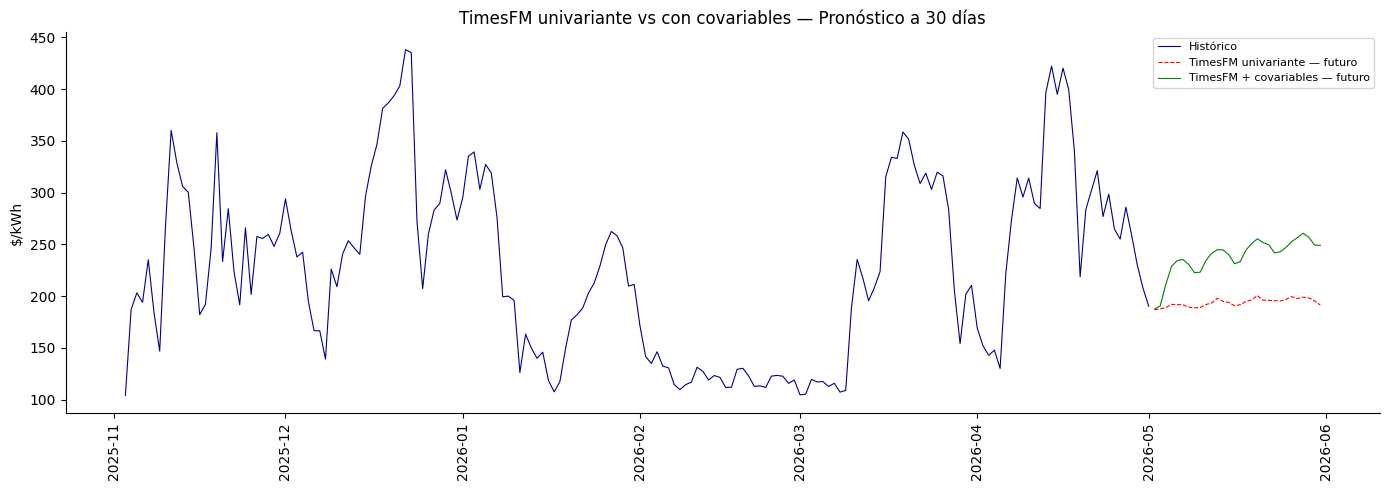

            univariante  con_covariables
2026-05-02   186.819519       187.604269
2026-05-03   187.688446       190.502475
2026-05-04   189.081909       211.578453
2026-05-05   192.042938       228.957584
2026-05-06   191.837601       234.377230
2026-05-07   191.608276       235.407321
2026-05-08   189.356293       230.556338
2026-05-09   188.779999       222.622512
2026-05-10   189.004333       223.199384
2026-05-11   191.927032       234.358248
2026-05-12   193.299469       241.322280
2026-05-13   198.001068       244.899059
2026-05-14   194.949127       244.612344
2026-05-15   193.882446       240.223320
2026-05-16   190.802063       231.332851
2026-05-17   191.701019       233.309143
2026-05-18   194.904205       244.485846
2026-05-19   196.345459       250.856680
2026-05-20   200.581085       255.415634
2026-05-21   196.104294       251.812162
2026-05-22   195.983978       249.617576
2026-05-23   195.648743       241.815243
2026-05-24   195.313034       242.803361
2026-05-25   196

In [16]:
dynamic_numerical_covariates_futuro = {
    col: [np.concatenate([df[col].values, df_covariables_futuras[col].values])]
    for col in covariables
}

model_timesfm.compile(
    timesfm.ForecastConfig(
        max_context=len(serie_completa),
        max_horizon=horizonte_futuro,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
        return_backcast=True,
    )
)

# Se infiere de la longitud de las covariables (contexto + horizonte)
point_forecast_cov_fut, quantile_forecast_cov_fut = model_timesfm.forecast_with_covariates(
    inputs=[serie_completa],
    dynamic_numerical_covariates=dynamic_numerical_covariates_futuro,
    dynamic_categorical_covariates=None,
    static_numerical_covariates=None,
    static_categorical_covariates=None,
    xreg_mode="xreg + timesfm",
)

pred_futuro_cov = pd.Series(np.asarray(point_forecast_cov_fut[0]), index=fechas_futuras, name='precio_bolsa')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[-180:], df['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Histórico')
ax.plot(df_forecast_futuro.index, df_forecast_futuro['Punto'], color='red', linewidth=0.8, linestyle='--', label='TimesFM univariante — futuro')
ax.plot(pred_futuro_cov.index, pred_futuro_cov, color='green', linewidth=0.8, label='TimesFM + covariables — futuro')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title(f'TimesFM univariante vs con covariables — Pronóstico a {horizonte_futuro} días')
sns.despine()
plt.tight_layout()
plt.show()

print(pd.DataFrame({'univariante': df_forecast_futuro['Punto'].values, 'con_covariables': pred_futuro_cov.values},
                    index=fechas_futuras))